# Phase 3b — Correlation & Root Cause Analysis
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D3 — Statistical Linkage between KPIs and Complaint Patterns  
**Author:** Ouerghi Chaima

---
## Table of Contents
1. Environment Setup
2. Load Data
3. Pearson & Spearman Correlation Matrices
4. KPI Threshold Detection
5. Granger Causality Testing
6. QoE Degradation Event Analysis
7. Cross-Correlation Functions (CCF)
8. D3 Summary — Key Findings


## 1. Environment Setup

In [110]:
import sys, os
PROJECT_ROOT = r'C:\Users\c50057188\Desktop\PFE_Ouerghi'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')
COLORS = sns.color_palette('husl', 10)
FIGURES = 'reports/figures'
os.makedirs(FIGURES, exist_ok=True)

print('Environment ready ✓')

Environment ready ✓


## 2. Load Data

In [111]:
complaint_agg  = pd.read_parquet('data/processed/complaint_daily_agg.parquet')
kpi_agg        = pd.read_parquet('data/processed/kpi_daily_agg.parquet')
feature_matrix = pd.read_parquet('data/processed/feature_matrix.parquet')

print(f'complaint_agg  : {complaint_agg.shape}')
print(f'kpi_agg        : {kpi_agg.shape}')
print(f'feature_matrix : {feature_matrix.shape}')
print('\nAll datasets loaded ✓')

complaint_agg  : (5460, 29)
kpi_agg        : (5460, 108)
feature_matrix : (5460, 162)

All datasets loaded ✓


In [112]:
from src.analysis.correlation import CorrelationAnalyser

analyser = CorrelationAnalyser()
results  = analyser.run(complaint_agg, kpi_agg, feature_matrix)

2026-03-30 05:43:11.487 | INFO     | src.analysis.correlation:run:115 - ============================================================
2026-03-30 05:43:11.489 | INFO     | src.analysis.correlation:run:116 - CORRELATION & ROOT CAUSE ANALYSIS  (D3)
2026-03-30 05:43:11.492 | INFO     | src.analysis.correlation:run:117 - ============================================================
2026-03-30 05:43:11.494 | INFO     | src.analysis.correlation:run:120 - 
[0/5] Joining complaint + KPI aggregates ...
2026-03-30 05:43:11.539 | INFO     | src.analysis.correlation:run:122 -   Joined dataset: 5,460 rows
2026-03-30 05:43:11.541 | INFO     | src.analysis.correlation:run:125 - 
[1/5] Computing Pearson & Spearman correlation matrices ...
2026-03-30 05:43:11.632 | INFO     | src.analysis.correlation:_correlation_matrices:255 -   Top 5 KPIs correlated with total_complaints (Pearson):
2026-03-30 05:43:11.636 | INFO     | src.analysis.correlation:_correlation_matrices:257 -     Data QoE Score               

## 3. Pearson & Spearman Correlation Matrices

In [113]:
# 3.1 Top correlations ranked table
top_corr = results['top_correlations']
print('=== KPI → Total Complaints Correlation Rankings ===')
display(top_corr[['kpi_label','pearson_r','pearson_p','pearson_sig',
                   'spearman_r','spearman_p','spearman_sig']])

=== KPI → Total Complaints Correlation Rankings ===


,kpi_label,pearson_r,pearson_p,pearson_sig,spearman_r,spearman_p,spearman_sig
0,Data QoE Score,-0.0259,0.0557,✗,-0.0227,0.0934,✗
1,DL Throughput (Mbps),-0.0223,0.0997,✗,-0.0258,0.0566,✗
2,Packet Loss (%),0.0200,0.1397,✗,0.0142,0.2935,✗
3,qoe_score_mean,-0.0188,0.1650,✗,-0.0165,0.2237,✗
4,Handover SR (%),-0.0166,0.2187,✗,-0.0173,0.1999,✗
5,Call Setup SR (%),-0.0093,0.4915,✗,-0.0127,0.3471,✗
6,UL Throughput (Mbps),-0.0075,0.5818,✗,-0.0109,0.4186,✗
7,Voice MOS,-0.0056,0.6780,✗,-0.0058,0.6670,✗
8,Voice QoE Score,-0.0049,0.7168,✗,-0.0053,0.6930,✗
9,Data Session SR (%),-0.0038,0.7764,✗,-0.0053,0.6969,✗


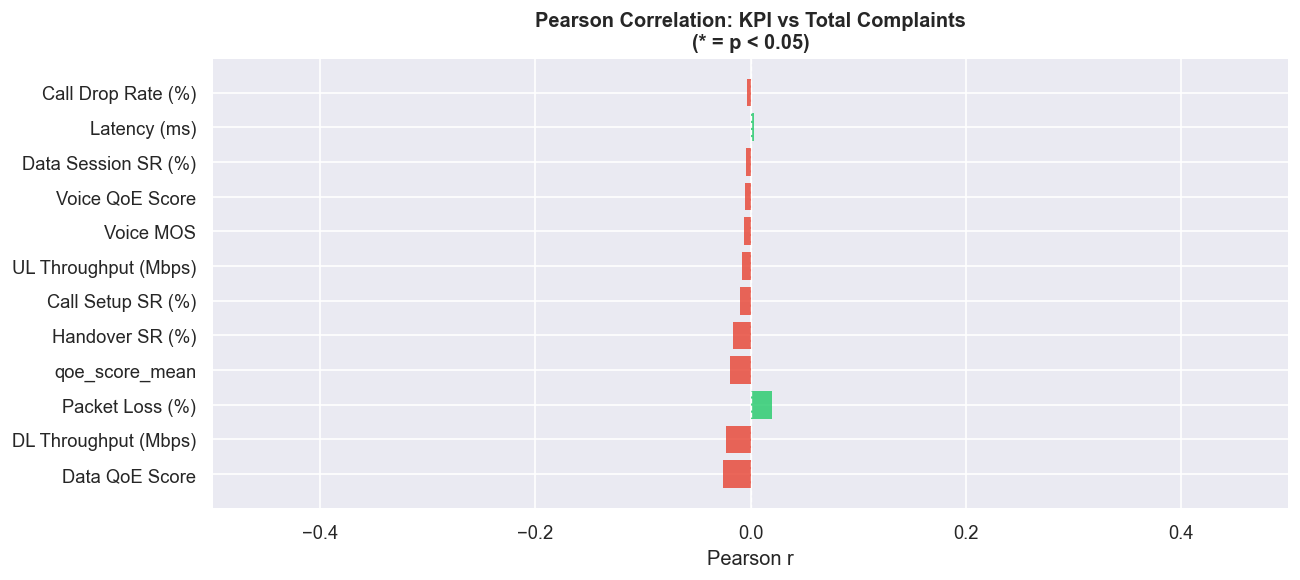

In [114]:
# 3.2 Bar chart — Pearson r for each KPI
fig, ax = plt.subplots(figsize=(11, 5))
colors  = ['#e74c3c' if r < 0 else '#2ecc71' for r in top_corr['pearson_r']]
bars    = ax.barh(top_corr['kpi_label'], top_corr['pearson_r'],
                  color=colors, edgecolor='none', alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')

# Significance markers
for i, (r, sig) in enumerate(zip(top_corr['pearson_r'], top_corr['pearson_sig'])):
    if sig == '✓':
        ax.text(r + (0.003 if r >= 0 else -0.003), i,
                '*', va='center', ha='left' if r >= 0 else 'right',
                fontsize=14, color='white')

ax.set_title('Pearson Correlation: KPI vs Total Complaints\n(* = p < 0.05)',
             fontweight='bold')
ax.set_xlabel('Pearson r')
ax.set_xlim(-0.5, 0.5)
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_pearson_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()

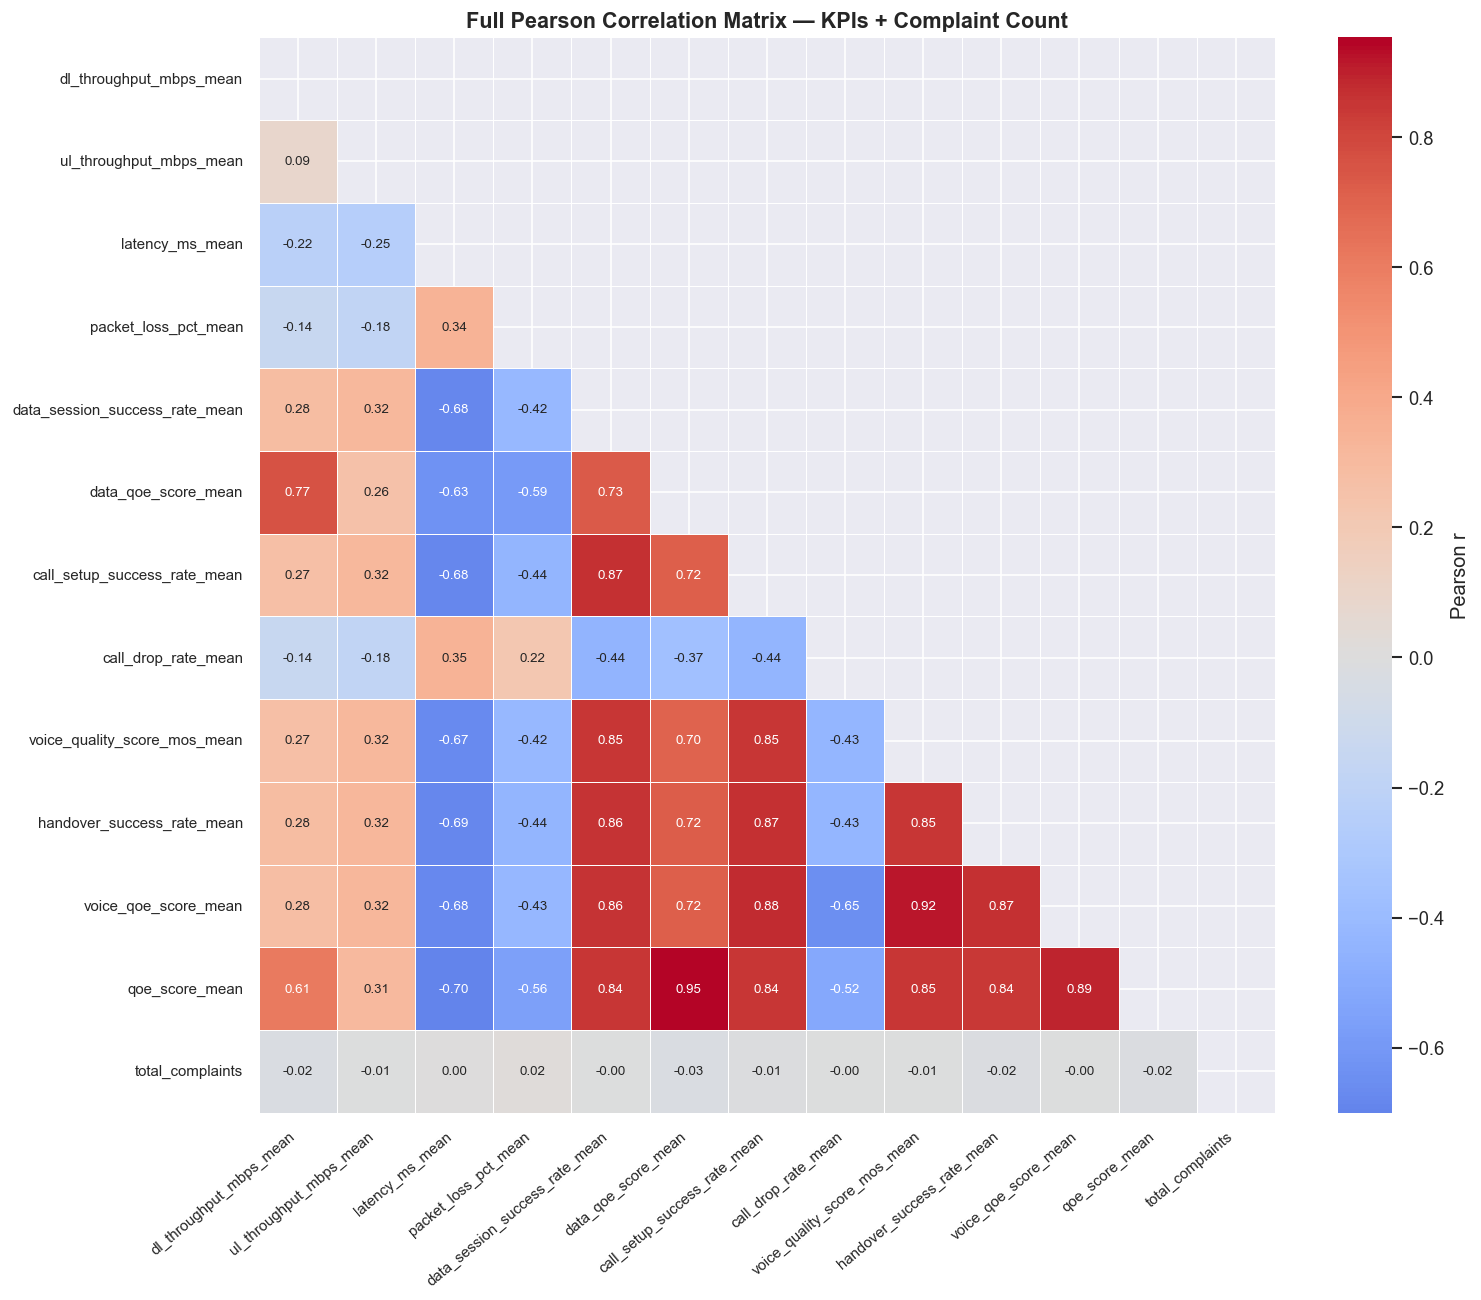

In [115]:
# 3.3 Full Pearson correlation heatmap (KPI × KPI × complaints)
pearson_mat = results['pearson_matrix']

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(pearson_mat, dtype=bool))
sns.heatmap(
    pearson_mat, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.4,
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Full Pearson Correlation Matrix — KPIs + Complaint Count',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_full_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

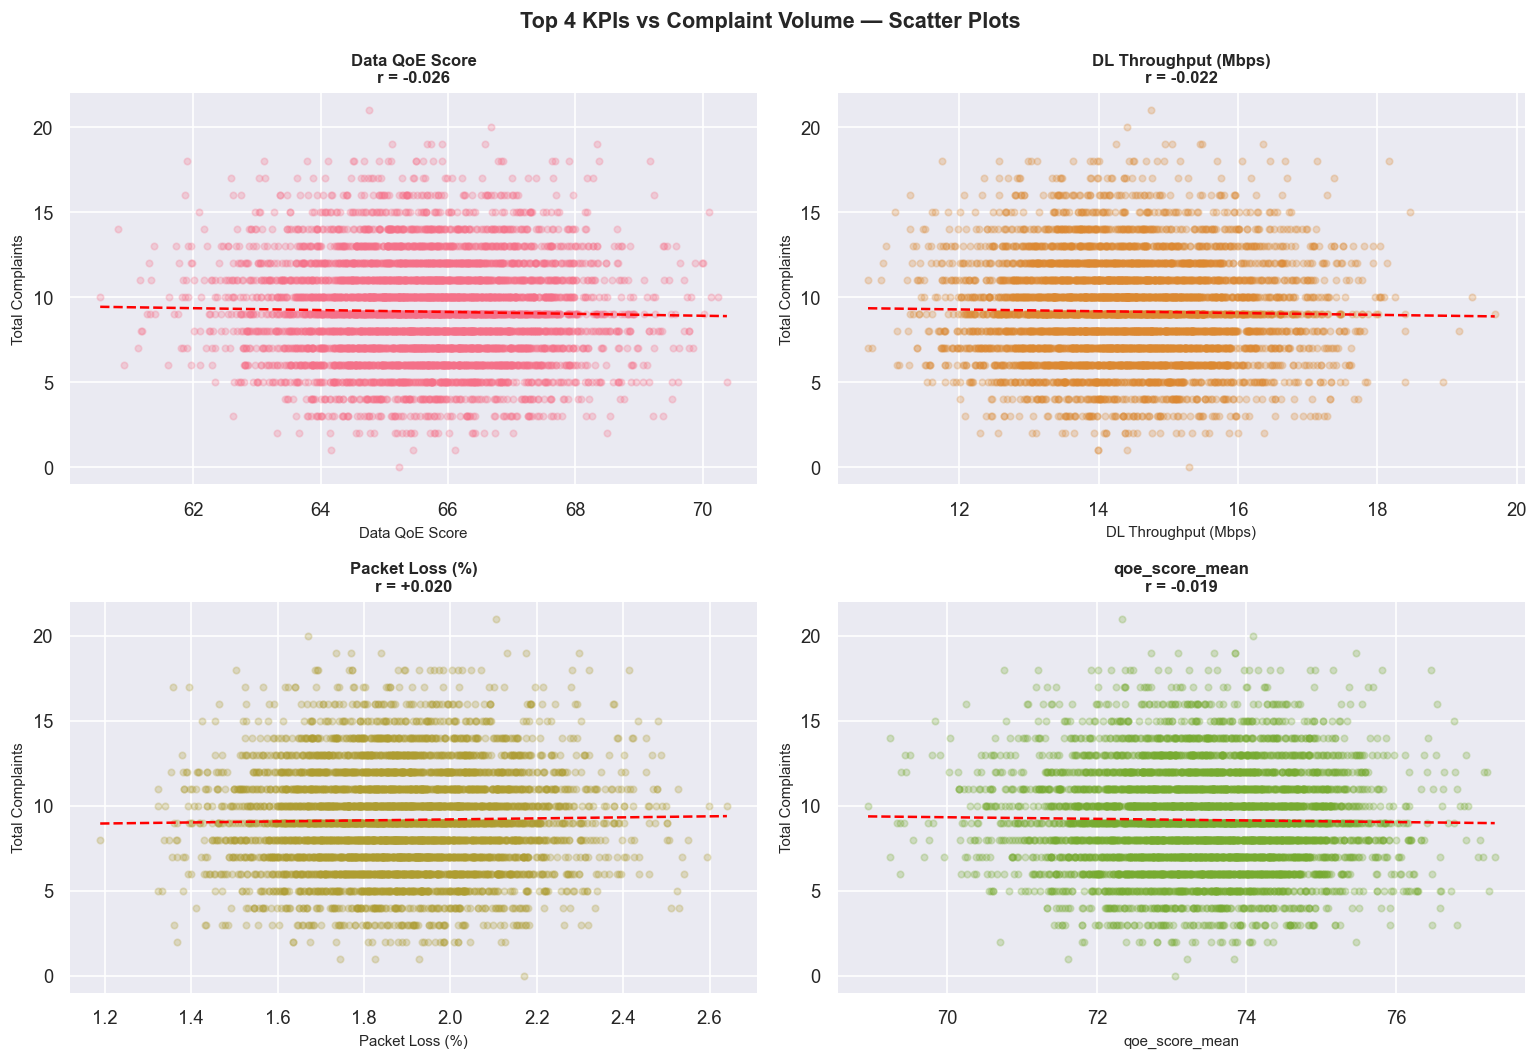

In [116]:
# 3.4 Scatter plots — top 4 correlated KPIs vs complaints
joined   = results['joined']
top4_kpi = top_corr['kpi'].head(4).tolist()
top4_lbl = top_corr['kpi_label'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (kpi, label) in enumerate(zip(top4_kpi, top4_lbl)):
    if kpi not in joined.columns:
        continue
    pair = joined[[kpi, 'total_complaints']].dropna()
    r    = top_corr.loc[top_corr['kpi'] == kpi, 'pearson_r'].values[0]

    axes[i].scatter(pair[kpi], pair['total_complaints'],
                    alpha=0.25, s=15, color=COLORS[i])
    # Trend line
    z = np.polyfit(pair[kpi], pair['total_complaints'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(pair[kpi].min(), pair[kpi].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--')

    axes[i].set_title(f'{label}\nr = {r:+.3f}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel(label, fontsize=9)
    axes[i].set_ylabel('Total Complaints', fontsize=9)

plt.suptitle('Top 4 KPIs vs Complaint Volume — Scatter Plots',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_kpi_complaint_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. KPI Threshold Detection

In [117]:
thresholds = results['thresholds']
print('=== KPI Complaint-Spike Thresholds ===')
display(thresholds[['kpi_label','threshold_value','direction',
                     'spike_rate_below','spike_rate_above','gini_improvement']])

=== KPI Complaint-Spike Thresholds ===


,kpi_label,threshold_value,direction,spike_rate_below,spike_rate_above,gini_improvement
0,Call Setup SR (%),96.550,above,0.027,1.000,0.00069
1,Handover SR (%),95.495,above,0.026,0.600,0.00060
2,Latency (ms),36.422,below,1.000,0.027,0.00035
3,Data Session SR (%),93.880,above,0.026,0.148,0.00015
4,Packet Loss (%),2.279,above,0.026,0.070,0.00011
5,Voice QoE Score,85.399,above,0.026,0.097,0.00011
6,DL Throughput (Mbps),11.304,below,0.125,0.027,0.00006
7,UL Throughput (Mbps),5.193,above,0.023,0.034,0.00006
8,Call Drop Rate (%),0.729,below,0.118,0.027,0.00005
9,Data QoE Score,65.677,below,0.032,0.022,0.00005


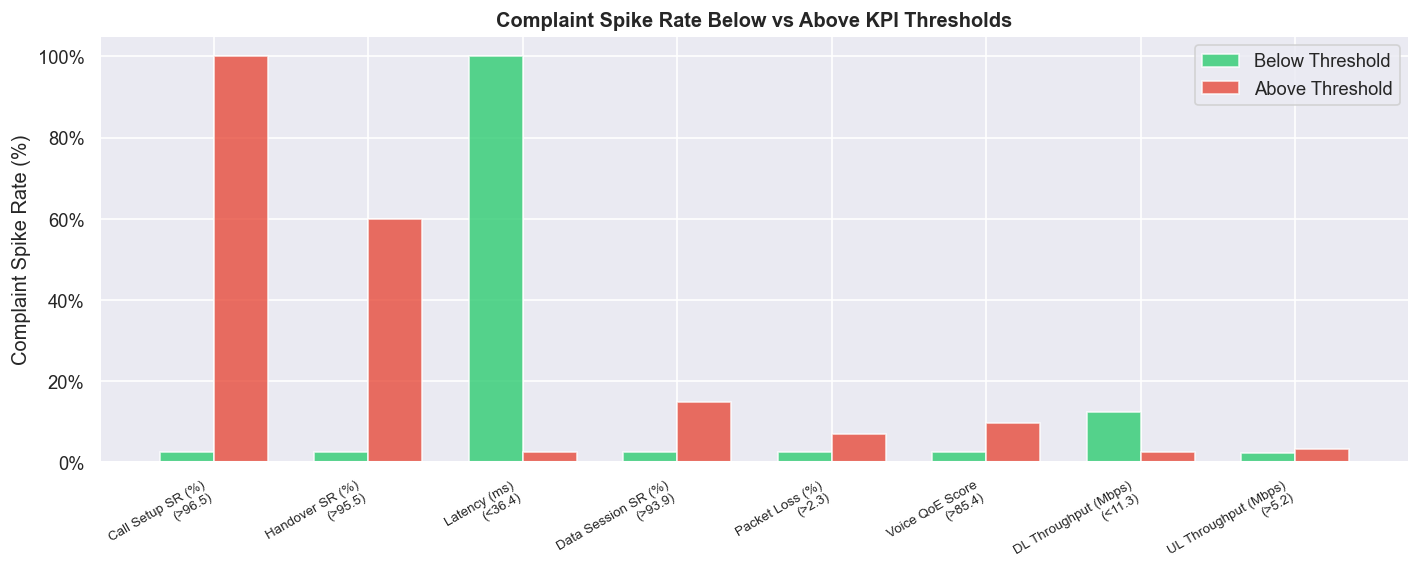

In [118]:
# 4.1 Threshold chart — spike rate below vs above threshold per KPI
thresh_top = thresholds.head(8).copy()

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(thresh_top))
width   = 0.35

ax.bar(x - width/2, thresh_top['spike_rate_below'] * 100,
       width, label='Below Threshold', color='#2ecc71', alpha=0.8)
ax.bar(x + width/2, thresh_top['spike_rate_above'] * 100,
       width, label='Above Threshold', color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{row['kpi_label']}\n(>{row['threshold_value']:.1f})" if row['direction']=='above'
     else f"{row['kpi_label']}\n(<{row['threshold_value']:.1f})"
     for _, row in thresh_top.iterrows()],
    rotation=30, ha='right', fontsize=8
)
ax.set_ylabel('Complaint Spike Rate (%)')
ax.set_title('Complaint Spike Rate Below vs Above KPI Thresholds',
             fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_kpi_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

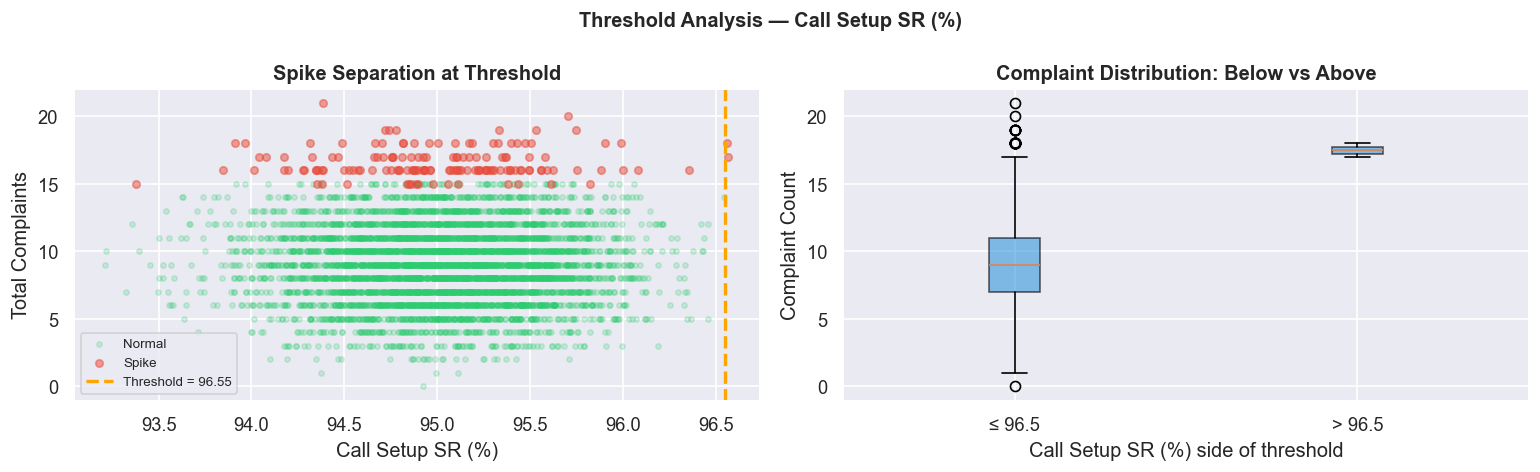

In [119]:
# 4.2 Threshold visualisation for the top KPI
if not thresholds.empty:
    best_kpi   = thresholds.iloc[0]['kpi']
    best_label = thresholds.iloc[0]['kpi_label']
    best_thresh= thresholds.iloc[0]['threshold_value']

    if best_kpi in joined.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        # Scatter with threshold line
        normal_pts = joined[joined['complaint_spike_flag'] == 0]
        spike_pts  = joined[joined['complaint_spike_flag'] == 1]
        axes[0].scatter(normal_pts[best_kpi], normal_pts['total_complaints'],
                        alpha=0.2, s=10, color='#2ecc71', label='Normal')
        axes[0].scatter(spike_pts[best_kpi], spike_pts['total_complaints'],
                        alpha=0.5, s=20, color='#e74c3c', label='Spike')
        axes[0].axvline(best_thresh, color='orange', linewidth=2,
                        linestyle='--', label=f'Threshold = {best_thresh:.2f}')
        axes[0].set_xlabel(best_label)
        axes[0].set_ylabel('Total Complaints')
        axes[0].set_title(f'Spike Separation at Threshold', fontweight='bold')
        axes[0].legend(fontsize=8)

        # Box plot: complaints below vs above threshold
        below_data = joined[joined[best_kpi] <= best_thresh]['total_complaints']
        above_data = joined[joined[best_kpi] >  best_thresh]['total_complaints']
        axes[1].boxplot([below_data.dropna(), above_data.dropna()],
                        labels=[f'≤ {best_thresh:.1f}', f'> {best_thresh:.1f}'],
                        patch_artist=True,
                        boxprops=dict(facecolor='#3498db', alpha=0.6))
        axes[1].set_xlabel(f'{best_label} side of threshold')
        axes[1].set_ylabel('Complaint Count')
        axes[1].set_title('Complaint Distribution: Below vs Above', fontweight='bold')

        plt.suptitle(f'Threshold Analysis — {best_label}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{FIGURES}/d3_threshold_detail.png', dpi=150, bbox_inches='tight')
        plt.show()

## 5. Granger Causality Testing

In [120]:
granger = results['granger_results']
if granger.empty:
    print('Granger results empty — statsmodels may not be installed')
else:
    print(f'Total tests: {len(granger)}')
    print(f'Significant (p < 0.05): {granger["is_significant"].sum()}')
    print()
    display(granger[granger['is_significant']][
        ['region','kpi_label','best_lag_days','min_p_value','interpretation']
    ].head(15))

Total tests: 60
Significant (p < 0.05): 6



,region,kpi_label,best_lag_days,min_p_value,interpretation
0,Gafsa,Data Session SR (%),3,0.01498,Data Session Success Rate Granger-causes compl...
1,Tunis,Packet Loss (%),4,0.01701,Packet Loss Pct Granger-causes complaints with...
2,Gafsa,UL Throughput (Mbps),6,0.02247,Ul Throughput Mbps Granger-causes complaints w...
3,Tunis,Data QoE Score,4,0.02564,Data Qoe Score Granger-causes complaints with ...
4,Gabes,DL Throughput (Mbps),1,0.03032,Dl Throughput Mbps Granger-causes complaints w...
5,Ariana,Packet Loss (%),2,0.04778,Packet Loss Pct Granger-causes complaints with...


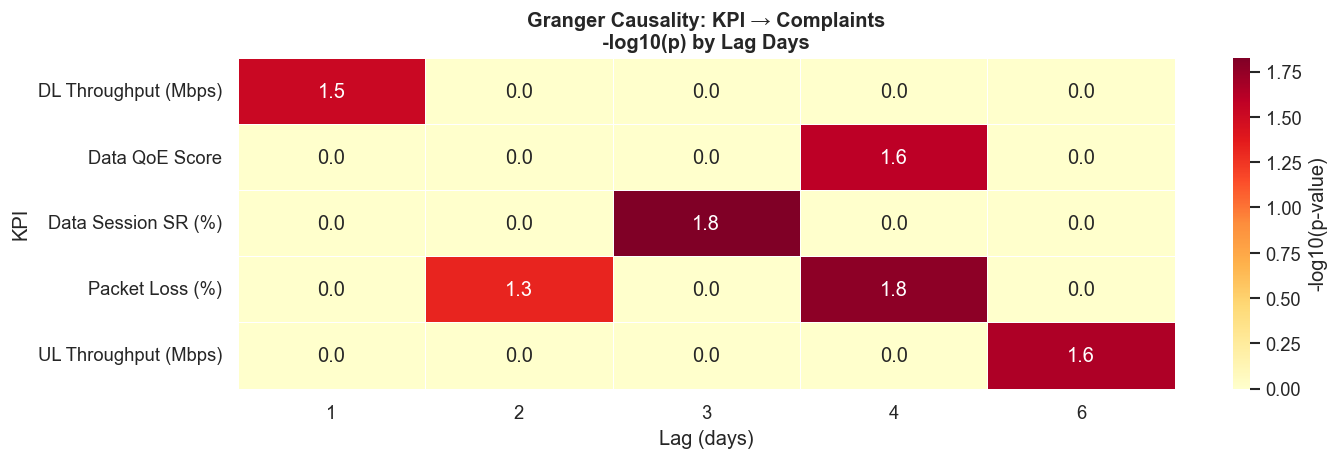

In [121]:
# 5.1 Granger heatmap — lag × KPI for significant results
if not granger.empty and granger['is_significant'].any():
    sig = granger[granger['is_significant']].copy()
    sig['neg_log_p'] = -np.log10(sig['min_p_value'].clip(1e-10))

    # Average over regions
    pivot = (
        sig.groupby(['kpi_label','best_lag_days'])['neg_log_p']
           .mean()
           .unstack(fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * 0.55)))
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f',
                linewidths=0.3, ax=ax,
                cbar_kws={'label': '-log10(p-value)'})
    ax.set_title('Granger Causality: KPI → Complaints\n-log10(p) by Lag Days',
                 fontweight='bold')
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('KPI')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/d3_granger_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No significant Granger results to plot — expected with synthetic data.')
    print('This section will show clear results with real operator data.')

## 6. QoE Degradation Event Analysis

In [122]:
qoe_events = results['qoe_event_analysis']
print('=== QoE Degradation → Complaint Impact ===')
display(qoe_events[['region','n_degraded_days','n_normal_days',
                     'mean_complaints_degraded','mean_complaints_normal',
                     'pct_increase','p_value','is_significant']])

=== QoE Degradation → Complaint Impact ===


,region,n_degraded_days,n_normal_days,mean_complaints_degraded,mean_complaints_normal,pct_increase,p_value,is_significant
0,Kairouan,141,405,9.48,9.05,4.7,0.07866,False
1,Gabes,131,415,9.27,9.04,2.6,0.21265,False
2,Monastir,120,426,9.40,9.21,2.1,0.21820,False
3,Ariana,137,409,9.40,9.21,2.0,0.23295,False
4,Ben Arous,123,423,9.26,9.12,1.6,0.37366,False
5,Gafsa,133,413,9.14,9.04,1.1,0.26021,False
6,Sousse,128,418,9.31,9.29,0.2,0.43546,False
7,Bizerte,124,422,9.18,9.18,-0.1,0.43486,False
8,Tunis,146,400,8.89,8.98,-1.0,0.83511,False
9,Sfax,129,417,9.04,9.20,-1.7,0.74410,False


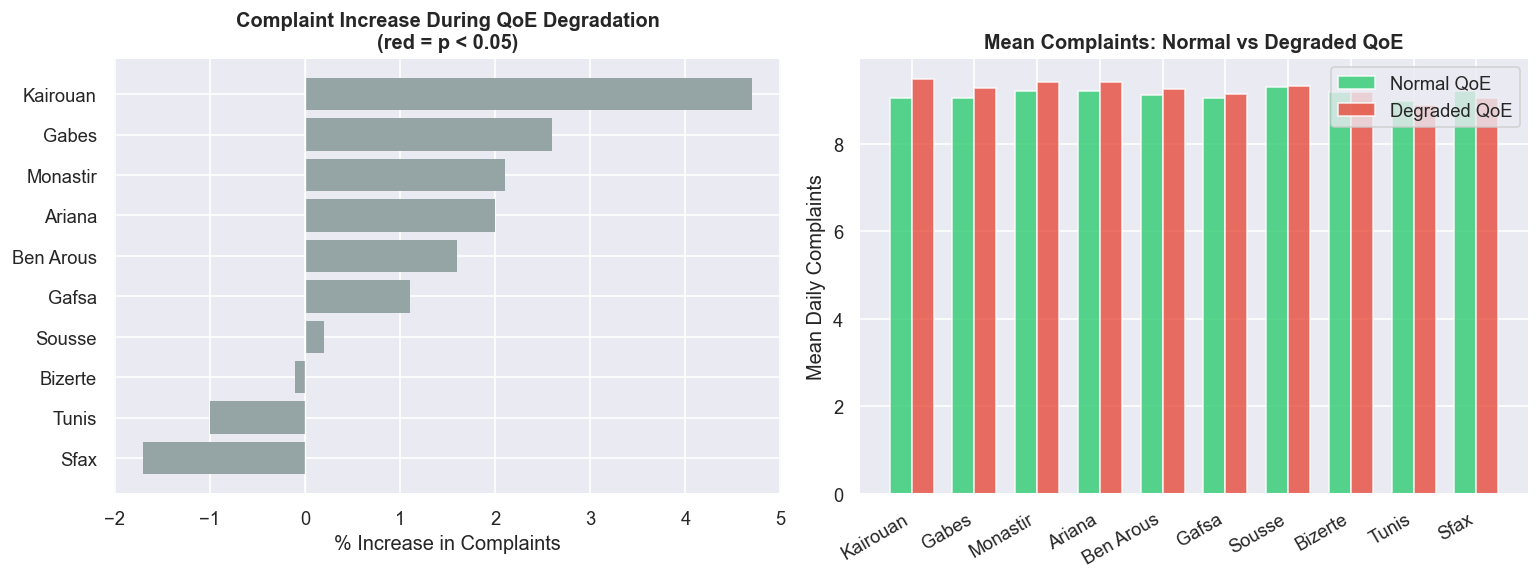

In [123]:
# 6.1 % complaint increase during QoE degradation — by region
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

qoe_sorted = qoe_events.sort_values('pct_increase', ascending=True)
colors_bar = ['#e74c3c' if sig else '#95a5a6'
               for sig in qoe_sorted['is_significant']]

axes[0].barh(qoe_sorted['region'], qoe_sorted['pct_increase'],
             color=colors_bar, edgecolor='none')
axes[0].axvline(0, color='white', linewidth=0.8)
axes[0].set_title('Complaint Increase During QoE Degradation\n(red = p < 0.05)',
                  fontweight='bold')
axes[0].set_xlabel('% Increase in Complaints')

# 6.2 Mean complaints: degraded vs normal grouped bar
x      = np.arange(len(qoe_events))
width  = 0.35
axes[1].bar(x - width/2, qoe_events['mean_complaints_normal'],
            width, label='Normal QoE', color='#2ecc71', alpha=0.8)
axes[1].bar(x + width/2, qoe_events['mean_complaints_degraded'],
            width, label='Degraded QoE', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(qoe_events['region'], rotation=30, ha='right')
axes[1].set_ylabel('Mean Daily Complaints')
axes[1].set_title('Mean Complaints: Normal vs Degraded QoE',
                  fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_qoe_degradation_impact.png', dpi=150, bbox_inches='tight')
plt.show()

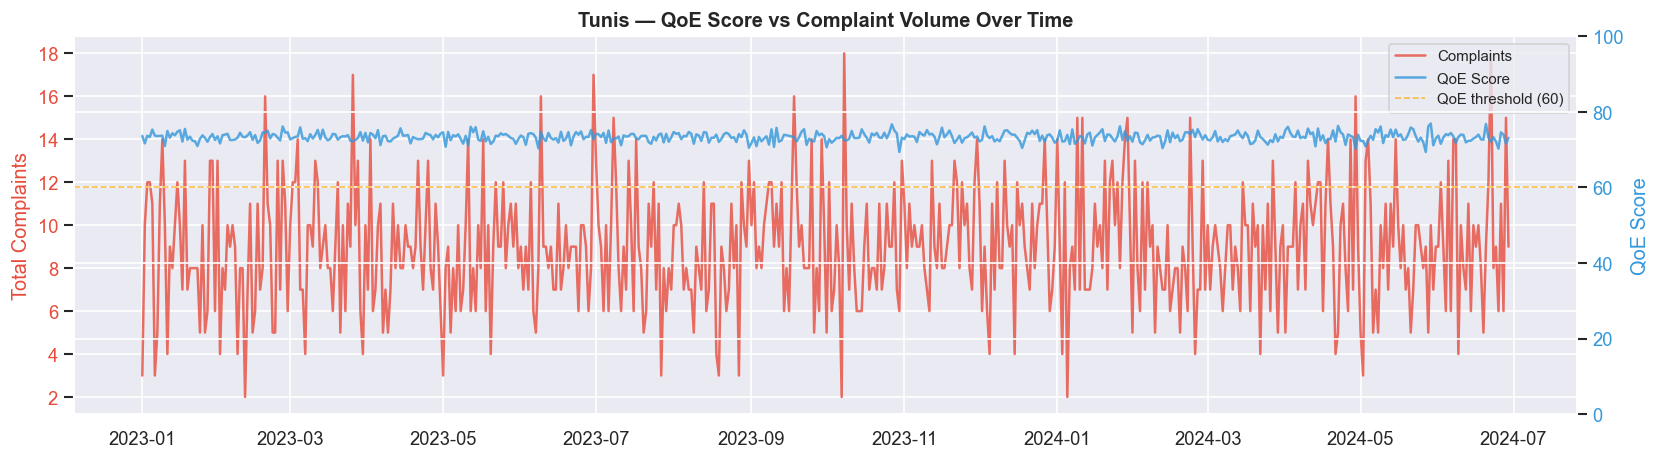

In [124]:
# 6.3 Timeline: QoE score vs complaint volume for one region
region  = 'Tunis'
ca_r    = complaint_agg[complaint_agg['region'] == region].sort_values('date')
ka_r    = kpi_agg[kpi_agg['region'] == region].sort_values('date').copy()

if 'qoe_score_mean' not in ka_r.columns:
    if 'data_qoe_score_mean' in ka_r.columns and 'voice_qoe_score_mean' in ka_r.columns:
        ka_r['qoe_score_mean'] = 0.55 * ka_r['data_qoe_score_mean'] + \
                                  0.45 * ka_r['voice_qoe_score_mean']

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(pd.to_datetime(ca_r['date']), ca_r['total_complaints'],
         color='#e74c3c', linewidth=1.5, alpha=0.8, label='Complaints')
ax1.set_ylabel('Total Complaints', color='#e74c3c')
ax1.tick_params(axis='y', labelcolor='#e74c3c')

if 'qoe_score_mean' in ka_r.columns:
    ax2.plot(pd.to_datetime(ka_r['date']), ka_r['qoe_score_mean'],
             color='#3498db', linewidth=1.5, alpha=0.8, label='QoE Score')
    ax2.axhline(60, color='orange', linestyle='--', linewidth=1,
                alpha=0.7, label='QoE threshold (60)')
    ax2.set_ylabel('QoE Score', color='#3498db')
    ax2.tick_params(axis='y', labelcolor='#3498db')
    ax2.set_ylim(0, 100)

ax1.set_title(f'{region} — QoE Score vs Complaint Volume Over Time',
              fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_qoe_vs_complaints_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cross-Correlation Functions (CCF)

In [125]:
ccf = results['ccf_results']
print('=== Cross-Correlation: KPI → Complaints (Peak Lag) ===')
display(ccf[['region','kpi_label','best_lag_days',
             'peak_correlation','direction']].head(15))

=== Cross-Correlation: KPI → Complaints (Peak Lag) ===


,region,kpi_label,best_lag_days,peak_correlation,direction
0,Sfax,Handover SR (%),11,0.1451,direct
1,Sfax,Latency (ms),11,-0.1422,inverse
2,Sfax,Call Setup SR (%),11,0.1400,direct
3,Tunis,Call Setup SR (%),4,0.1377,direct
4,Sfax,Packet Loss (%),11,-0.1361,inverse
5,Sfax,Data QoE Score,11,0.1339,direct
6,Ariana,Data Session SR (%),12,0.1305,direct
7,Ariana,Packet Loss (%),0,0.1242,direct
8,Ariana,Call Setup SR (%),12,0.1232,direct
9,Sfax,Voice QoE Score,11,0.1212,direct


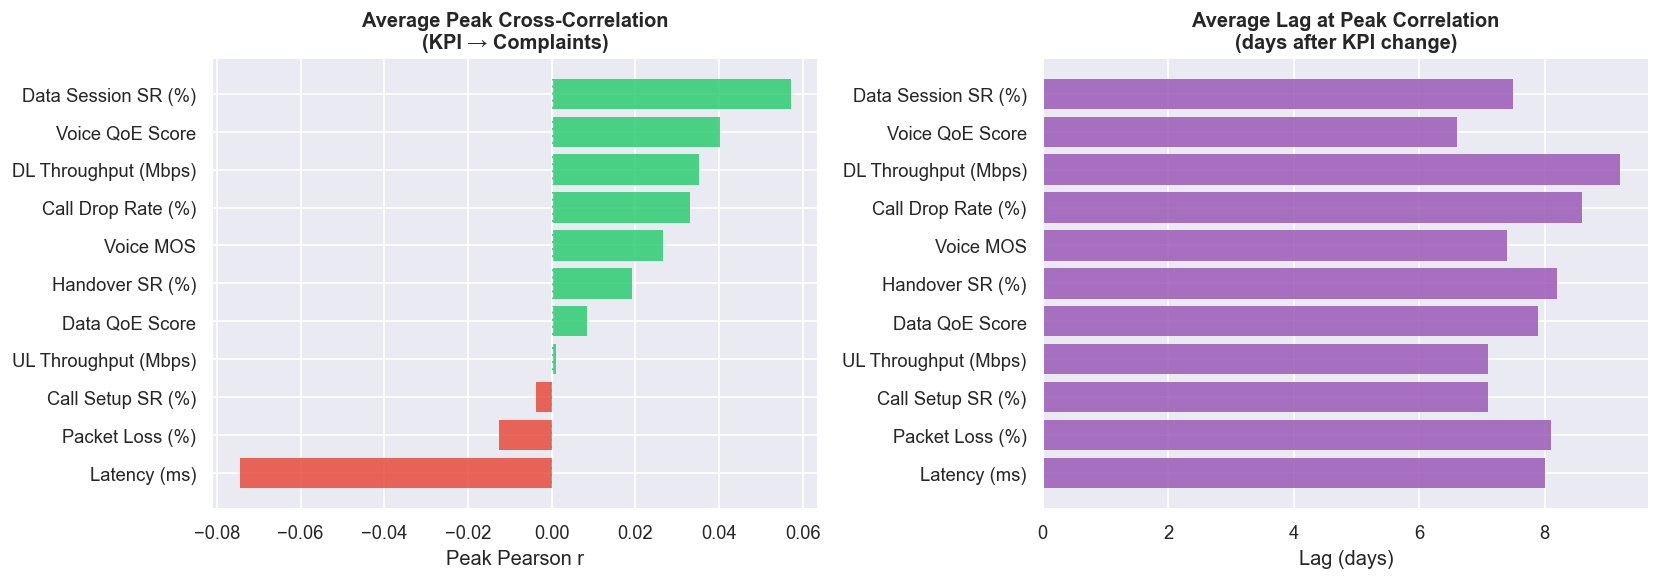

In [126]:
# 7.1 Average peak lag per KPI across all regions
if not ccf.empty:
    avg_lag = (
        ccf.groupby('kpi_label')
           .agg(avg_lag=('best_lag_days','mean'),
                avg_corr=('peak_correlation','mean'))
           .reset_index()
           .sort_values('avg_corr')
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Peak correlation
    colors_ccf = ['#e74c3c' if r < 0 else '#2ecc71' for r in avg_lag['avg_corr']]
    axes[0].barh(avg_lag['kpi_label'], avg_lag['avg_corr'],
                 color=colors_ccf, edgecolor='none', alpha=0.85)
    axes[0].axvline(0, color='white', linewidth=0.8, linestyle='--')
    axes[0].set_title('Average Peak Cross-Correlation\n(KPI → Complaints)',
                      fontweight='bold')
    axes[0].set_xlabel('Peak Pearson r')

    # Average lag
    axes[1].barh(avg_lag['kpi_label'], avg_lag['avg_lag'],
                 color='#9b59b6', edgecolor='none', alpha=0.85)
    axes[1].set_title('Average Lag at Peak Correlation\n(days after KPI change)',
                      fontweight='bold')
    axes[1].set_xlabel('Lag (days)')

    plt.tight_layout()
    plt.savefig(f'{FIGURES}/d3_ccf_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

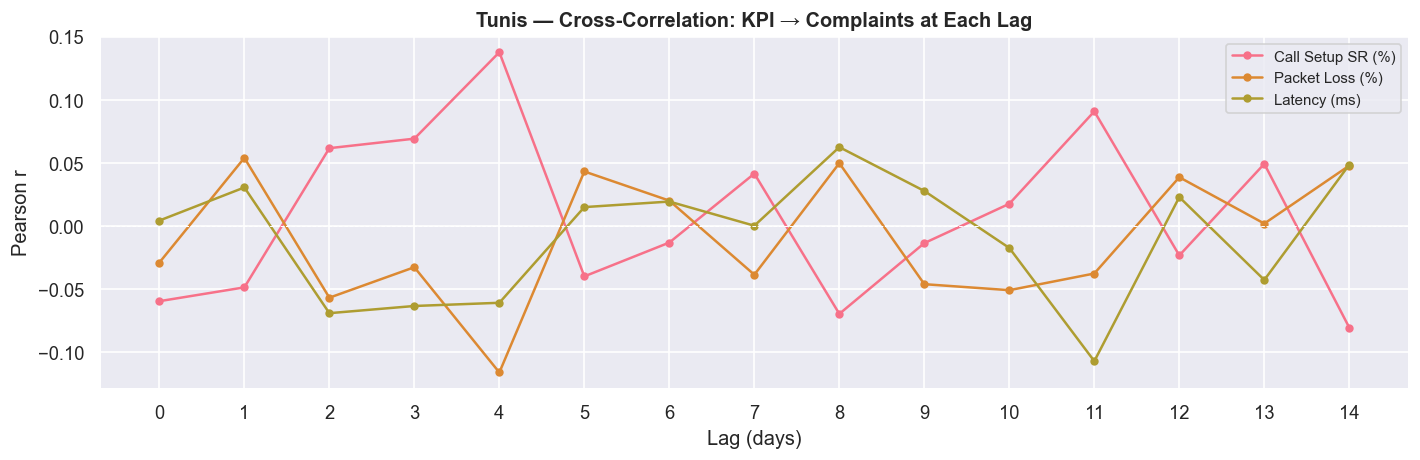

In [127]:
# 7.2 CCF plot for one region — lag profile for top KPI
from scipy.stats import pearsonr

region     = 'Tunis'
max_lag    = 14
ca_r       = complaint_agg[complaint_agg['region'] == region].sort_values('date')
ka_r       = kpi_agg[kpi_agg['region'] == region].sort_values('date')
merged_ccf = ca_r[['date','total_complaints']].merge(
    ka_r, on='date', how='inner'
).dropna().reset_index(drop=True)

top_kpi_for_ccf = ccf[ccf['region'] == region].sort_values(
    'abs_correlation', ascending=False
).head(3)

fig, ax = plt.subplots(figsize=(12, 4))
for i, (_, row) in enumerate(top_kpi_for_ccf.iterrows()):
    kpi_col  = row['kpi']
    kpi_lbl  = row['kpi_label']
    if kpi_col not in merged_ccf.columns:
        continue
    lags  = range(0, max_lag + 1)
    r_vals= []
    for lag in lags:
        if lag == 0:
            x, y = merged_ccf[kpi_col].values, merged_ccf['total_complaints'].values
        else:
            x, y = merged_ccf[kpi_col].values[:-lag], merged_ccf['total_complaints'].values[lag:]
        r, _ = pearsonr(x, y) if len(x) > 5 else (0, 1)
        r_vals.append(r)
    ax.plot(list(lags), r_vals, marker='o', markersize=4,
            linewidth=1.5, label=kpi_lbl, color=COLORS[i])

ax.axhline(0, color='white', linewidth=0.6, linestyle='--')
ax.set_title(f'{region} — Cross-Correlation: KPI → Complaints at Each Lag',
             fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Pearson r')
ax.legend(fontsize=9)
ax.set_xticks(range(0, max_lag + 1))
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_ccf_lag_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. D3 Summary — Key Findings

In [128]:
summary = results['summary']

print('=' * 60)
print('  D3 — CORRELATION STUDY: KEY FINDINGS')
print('=' * 60)

if 'top_correlated_kpis' in summary:
    print('\n  Most correlated KPIs with complaint volume:')
    for kpi, r in zip(summary['top_correlated_kpis'], summary['top_pearson_r']):
        print(f'    {kpi:<40} r = {r:+.3f}')

if 'most_predictive_threshold' in summary:
    t = summary['most_predictive_threshold']
    print(f'\n  Best KPI threshold for spike detection:')
    print(f'    {t["kpi"]} {t["direction"]} {t["threshold"]}')

if 'granger_significant_pairs' in summary:
    print(f'\n  Granger causality: {summary["granger_significant_pairs"]} significant pairs')
    if 'strongest_granger_cause' in summary:
        g = summary['strongest_granger_cause']
        print(f'    Strongest: {g["kpi"]} (lag={g["lag"]}d, p={g["p_value"]:.4f})')

if 'qoe_degradation_impact' in summary:
    q = summary['qoe_degradation_impact']
    print(f'\n  QoE degradation impact:')
    print(f'    Significant regions: {q["significant_regions"]}')
    print(f'    Max complaint spike : +{q["max_pct_increase"]:.1f}%')
    print(f'    Avg complaint spike : +{q["avg_pct_increase"]:.1f}%')

print()
print('  Report tables saved to reports/exports/  ✓')
print('  Figures saved to reports/figures/        ✓')
print('=' * 60)

print()
print('  Files produced for D3 deliverable:')
import os
for f in os.listdir('reports/exports'):
    if f.startswith('d3_'):
        print(f'    reports/exports/{f}')

  D3 — CORRELATION STUDY: KEY FINDINGS

  Most correlated KPIs with complaint volume:
    Data QoE Score                           r = -0.026
    DL Throughput (Mbps)                     r = -0.022
    Packet Loss (%)                          r = +0.020

  Best KPI threshold for spike detection:
    Call Setup SR (%) above 96.55

  Granger causality: 6 significant pairs
    Strongest: Data Session SR (%) (lag=3d, p=0.0150)

  QoE degradation impact:
    Significant regions: 0
    Max complaint spike : +4.7%
    Avg complaint spike : +1.2%

  Report tables saved to reports/exports/  ✓
  Figures saved to reports/figures/        ✓

  Files produced for D3 deliverable:
    reports/exports/d3_correlation_rankings.csv
    reports/exports/d3_cross_correlation.csv
    reports/exports/d3_granger_causality.csv
    reports/exports/d3_kpi_thresholds.csv
    reports/exports/d3_qoe_event_analysis.csv
